# Time-Reversal Refocusing in Homogeneous and Randomly Heterogeneous Media

**Author:** Damien Rouchouse

In this project, I study the physics of wave time-reversal using numerical simulations. The main goal is to show that time-reversal refocusing actually works better when waves propagate in a randomly heterogeneous medium rather than in a simple homogeneous one.

To simulate this, I used the paraxial wave equation and implemented the Split-Step Fourier method. To keep this notebook readable and to focus on the physics and the results, I moved most of the core computational code (solvers, operators, random process generation) into a custom Python package called `time_reversal`.

Here is a quick breakdown of what I explore in this notebook:
* **The Homogeneous Case:** I first simulate forward propagation and time-reversal in a homogeneous medium to observe the classical diffraction limit (how a finite-sized mirror blurs the refocused spot).
* **The Random Medium:** I simulate the propagation in the random medium by sampling a gaussian process an use split-step Fourier method.
* **Super-Resolution:** By performing time-reversal in the same random medium, I show that the multiple scattering paths actually help funnel information back to the mirror, creating a much sharper focal spot.
* **Broadband Pulses:** Finally, I move from single-frequency waves to time-dependent broadband pulses to demonstrate "self-averaging". This shows that with realistic broadband signals, the refocusing is statistically stable and doesn't even need Monte Carlo averaging.



##  Preliminaries

Let $u(\mathbf{x}, t)$ for $(\mathbf{x}, t) \in \mathbb{R}^2 \times [0, +\infty)$ be a scalar wave field. It satisfies the standard wave equation:
$$
    \left( \frac{1}{c(\mathbf{x})^2}\partial_t^2 - \Delta \right) u(\mathbf{x}, t) = 0.
$$

By applying a Fourier transform with respect to time, we transition to the frequency domain, obtaining the corresponding Helmholtz equation:
$$
\left( \frac{\omega^2}{c(\mathbf{x})^2} + \Delta \right) \hat{u}(\mathbf{x}, \omega) = 0.
$$

In [1]:
get_ipython().run_line_magic("matplotlib", "inline")
import dataclasses
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tqdm

# Custom package imports
from time_reversal.config import SimulationConfig
from time_reversal.propagation_fun import (
    compute_theoretical_broadband_refocused,
    homogeneous_analytic_solution,
    homogeneous_time_reversal_analytic_solution,
    init_homogeneous,
    mean_field_mixed_medium_refocused,
    mean_field_random_medium_refocused,
    mean_intensity,
)
from time_reversal.simulation import run_monte_carlo_simulation, run_single_simulation
from time_reversal.viz import (
    plot_complex_comparison,
    plot_intensity_grid,
    plot_intensity_map,
    plot_intensity_section,
    plot_multiple_intensity_section,
    setup_style,
)

setup_style()

## Paraxial Approximation in a Homogeneous Medium

We first assume a homogeneous medium with a constant wave velocity $c(\mathbf{x}) = c_0$.
We factorize the spatial field as $\hat{u}_\omega(\mathbf{x}) = \phi(\mathbf{x}) e^{ikz}$, where $k = \omega/c_0$.

Under the paraxial approximation ($|\partial_z^2 \phi| \ll |2k\partial_z \phi|$), the Helmholtz equation simplifies to the paraxial Schrödinger equation
$$
2ik\partial_z \phi(\mathbf{x}) + \partial_x^2 \phi(\mathbf{x}) = 0.
$$

We consider a time-harmonic initial condition at $z = 0$ with a transverse Gaussian profile of radius $r_0$
$$ \phi(z =0, x) = \phi_0(x) = \exp\left(-\frac{x^2}{r_0^2}\right). $$

The analytical solution at a propagation distance $z=L$ is given by
$$ \phi_t(x) = \frac{r_0}{r_t} \exp\left(- \frac{x^2}{r_t^2}\right), \quad \text{with } r_t = r_0 \sqrt{1 + \frac{2iL}{kr_0^2}}. $$

Let's run a simulation for a fixed frequency and compare the numerical result with this theoretical derivation.

In [2]:
# Initialize the global simulation configuration
cfg = SimulationConfig(
    c0=1.0,
    w=1.0,
    L=10.0,
    r0=2.0,
    x_size=60.0,
    nx=1024,
    h=0.1,
    z_c=1.0,
    x_c=4.0,
    sigma=0.0,  # 0.0 means homogeneous medium
    mirror_type="gaussian",
    r_m=20.0,
    n_monte_carlo=100,
)


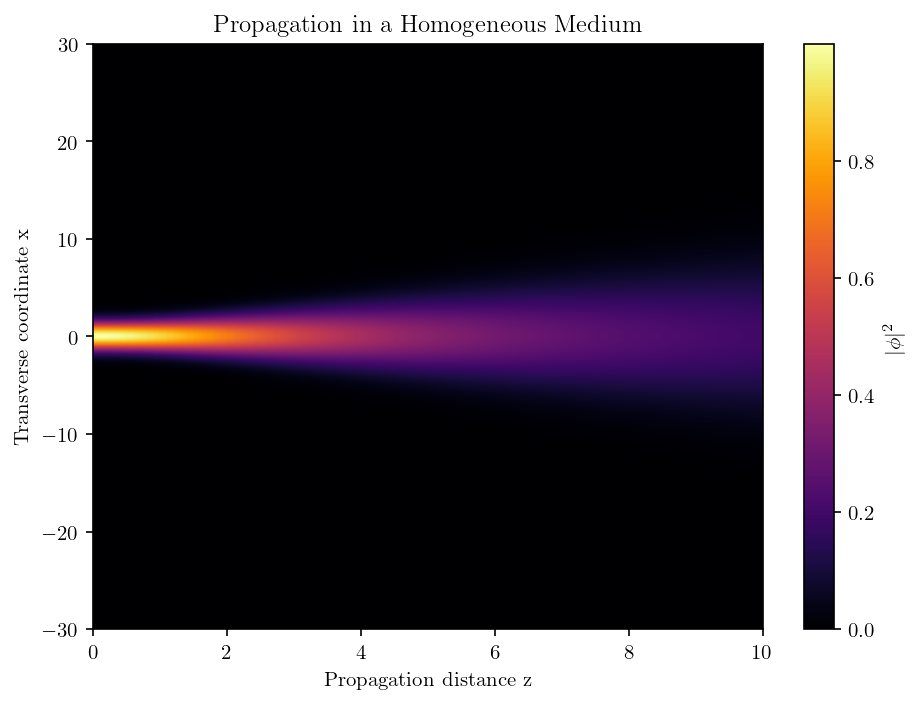

In [3]:
# Run forward simulation
res_hom = run_single_simulation(cfg, return_history=True)

# Extract forward history (from z=0 to z=L)
n_steps = res_hom.history.shape[0]
forward_history = res_hom.history[: n_steps // 2, :]

plot_intensity_map(
    np.abs(forward_history).T ** 2,
    extent=[0, cfg.L, cfg.x_min, cfg.x_max],
    title="Propagation in a Homogeneous Medium",
    xlabel="Propagation distance z",
    ylabel="Transverse coordinate x",
    show=True,
)

### Theoretical Validation at the Mirror Plane ($z=L$)

Here, we verify that the theoretical expression for the profile of $\phi$ at $z=L$ matches the simulation. To do so, we compare their squared magnitudes.

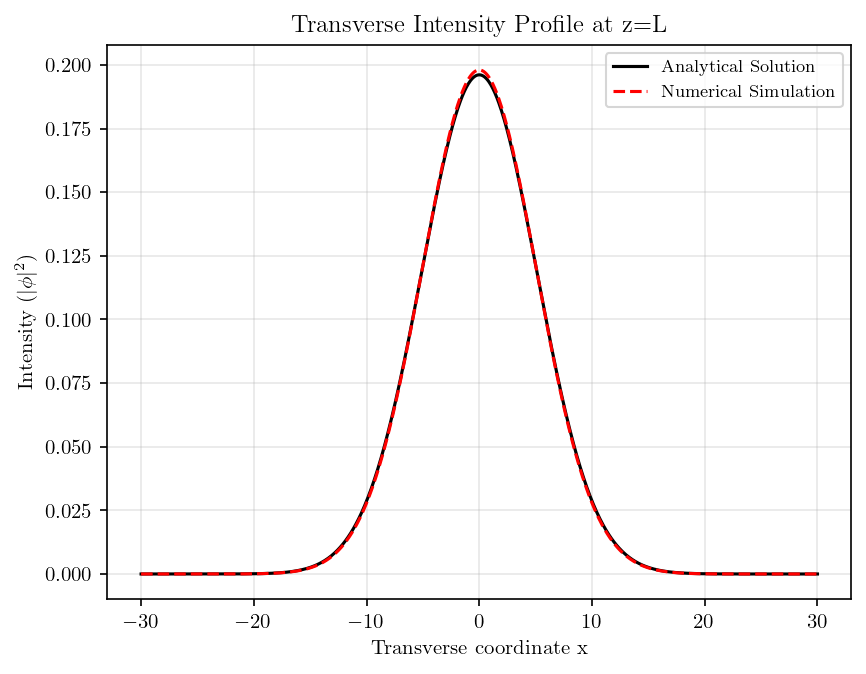

In [4]:
x = np.linspace(cfg.x_min, cfg.x_max, cfg.nx)
analytic_final = homogeneous_analytic_solution(
    x, length=cfg.L, r0=cfg.r0, k_const=cfg.k_const
)

plot_intensity_section(
    x,
    psi_num=forward_history[-1],
    psi_theory=analytic_final,
    title="Transverse Intensity Profile at z=L",
    xlabel="Transverse coordinate x",
    ylabel=r"Intensity ($|\phi|^2$)",
    label_curve1="Numerical Simulation",
    label_curve2="Analytical Solution",
    show=True,
);

The numerical profile perfectly matches the analytical solution, validating our forward solver.

## Time Reversal in a Homogeneous Medium

We now simulate the time-reversal process. We place a Gaussian time-reversal mirror in the plane $z = L$ with a aperture function
$$ \chi_M(x) = \exp\left(-\frac{x^2}{r_M^2}\right).$$

The recorded wave is phase-conjugated (which is equivalent to time reversal in the frequency domain) and back-propagated to the source plane $z=2L$. The theoretical refocused wave profile at $z=2L$ is
$$ \phi_r^{\mathrm{tr}}(x) = \frac{1}{a_{\mathrm{tr}}}\exp\left(-\frac{x^2}{r_{\mathrm{tr}}^2}\right)$$
where $a_{\mathrm{tr}} = \sqrt{1 + \frac{4L^2}{k^2r_0^2 r_M^2} + \frac{2iL}{kr_M^2}}$ and $r_{\mathrm{tr}}^2 = \left(\frac{1}{r_M^2} + \frac{1}{r_0^2 - 2i \frac{L}{k}} \right)^{-1} + \frac{2iL}{k}$.

### Simulating the Back-Propagation
Below, we plot the time reversal process.

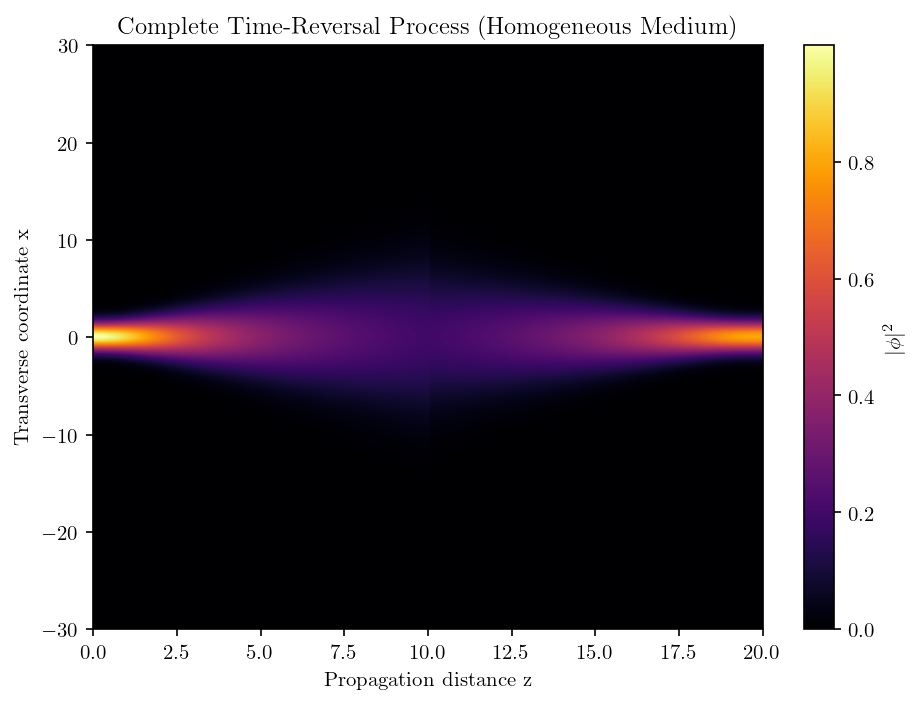

In [5]:
res_tr_hom = run_single_simulation(cfg, return_history=True)

plot_intensity_map(
    np.abs(res_tr_hom.history).T ** 2,
    extent=[0, 2 * cfg.L, cfg.x_min, cfg.x_max],
    title="Complete Time-Reversal Process (Homogeneous Medium)",
    xlabel="Propagation distance z",
    ylabel="Transverse coordinate x",
    show=True,
)

The first impression is that it correctly refocused around $x=0$ at $z=2L$, which is consistent with the expected behavior.

### Validation at the Focal Plane ($z=2L$)

As done before for the section at $z=L$, we can compare our simulation to the theoretical simulation.

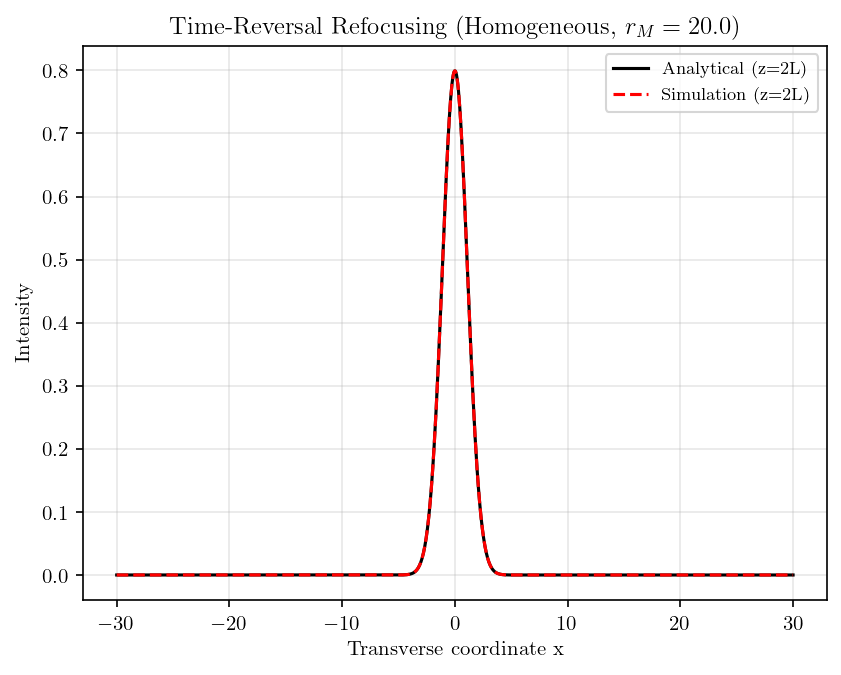

In [6]:
# Compute the analytical time-reversal profile
analytic_tr = homogeneous_time_reversal_analytic_solution(
    x, length=cfg.L, r0=cfg.r0, k_const=cfg.k_const, r_m=cfg.r_m
)

plot_intensity_section(
    x,
    psi_num=res_tr_hom.phi_final,
    psi_theory=analytic_tr,
    title=f"Time-Reversal Refocusing (Homogeneous, $r_M={cfg.r_m}$)",
    xlabel="Transverse coordinate x",
    ylabel="Intensity",
    label_curve1="Simulation (z=2L)",
    label_curve2="Analytical (z=2L)",
    show=True,
);

It is clear once again that it matches correcty the theoretical formula, validating our backward solver.

#### The Diffraction Limit: Influence of the Mirror Size
In the previous step, a very large mirror ($r_M = 20$) was used, capturing almost all the wave's information. We now consider the case of a smaller mirror (still infinite in practice since it is gaussian mirror, but with very low $r_M$), where the diffraction limit leads to a loss of information.

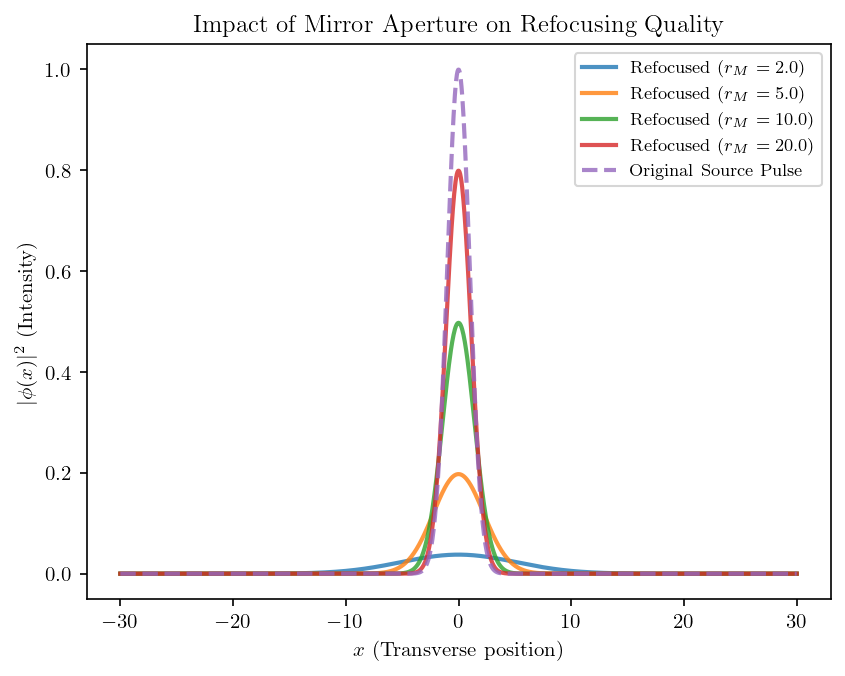

In [7]:
rm_list = [2.0, 5.0, 10.0, 20.0]
data = []

for rm in rm_list:
    cfg.r_m = rm # change mirror size
    res_tr_hom_temp = run_single_simulation(cfg, return_history=False)
    data.append([res_tr_hom_temp.phi_final, rf"Refocused ($r_M = {rm}$)", None])

# Add the original initial source pulse for comparison
data.append((res_tr_hom.phi_init, "Original Source Pulse", "--"))

plot_multiple_intensity_section(
    x,
    data_list=data,
    title="Impact of Mirror Aperture on Refocusing Quality",
    xlabel=r"$x$ (Transverse position)",
    ylabel=r"$|\phi(x)|^2$ (Intensity)",
    show=True,
);

As expected, in a homogeneous medium, a smaller mirror captures fewer spatial frequencies. Consequently, the refocused spot becomes wider and less intense. We lose resolution. We can observe the same property with a compact mirror.

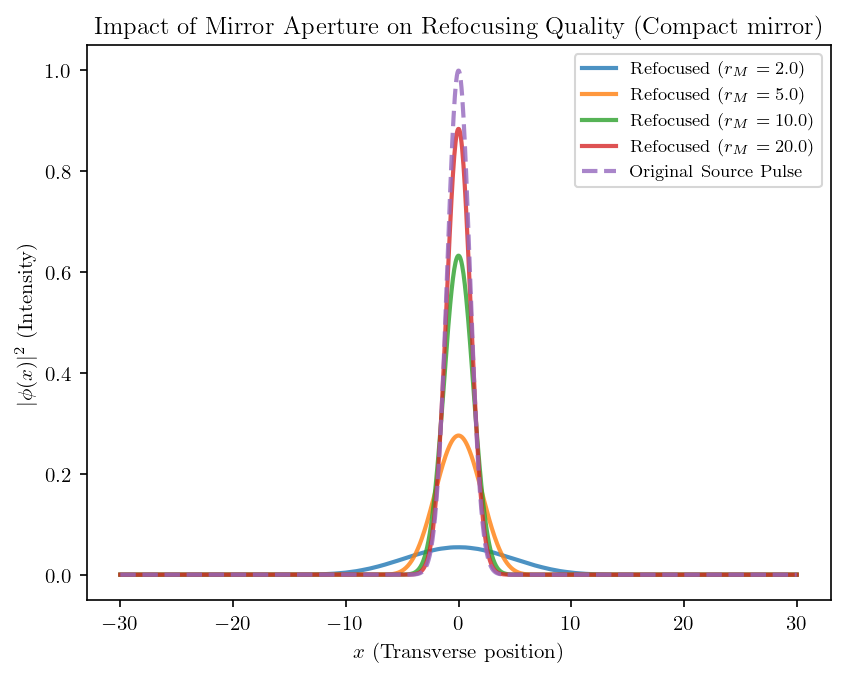

In [8]:
rm_list = [2.0, 5.0, 10.0, 20.0]
data = []
cfg.mirror_type="compact"

for rm in rm_list:    
    cfg.r_m = rm # change mirror size
    res_tr_hom_temp = run_single_simulation(cfg, return_history=False)
    data.append([res_tr_hom_temp.phi_final, rf"Refocused ($r_M = {rm}$)", None])

# Add the original initial source pulse for comparison
data.append((res_tr_hom.phi_init, "Original Source Pulse", "--"))

plot_multiple_intensity_section(
    x,
    data_list=data,
    title="Impact of Mirror Aperture on Refocusing Quality (Compact mirror)",
    xlabel=r"$x$ (Transverse position)",
    ylabel=r"$|\phi(x)|^2$ (Intensity)",
    show=True,
);

## Paraxial Approximation in a Random Medium

We now introduce random heterogeneities to the medium, representing fluctuations in the refractive index. The wave equation is modified to include a random potential $\mu(z,x)$
$$
     \partial_z \phi = \frac{i}{2k}\partial_x^2\phi + \frac{ik}{2}\mu(z,x)\phi.
$$
We model the medium as piecewise constant along the propagation axis $z$ with a correlation length $z_c$. Transversally, the fluctuations follow a Gaussian covariance $\mathbb{E}[\mu_n(x)\mu_n(x')] = \sigma^2 \exp(-(x-x')^2/x_c^2)$.

### The Split-Step Fourier Method
Because the diffraction operator (diagonal in Fourier space) and the refraction operator (diagonal in real space) do not commute, we cannot solve this exactly in one step. Instead, we use the Trotter-Kato formula to split the operators over a small step $h$
$$ \phi(z+h, x) \approx \exp\left( \frac{ik h}{2} \mu(z, x) \right) \mathcal{F}^{-1} \left[ \exp\left(-\frac{i h \kappa^2}{2k}\right) \mathcal{F}[\phi(z, x)] \right]. $$
Here is a summary of the method.
<div align="center" style="background-color: #f5f5f5; padding: 20px; border-radius: 8px;">
  <img src="../fig/fig.pdf"  style="max-width: 100%;">
</div>

### Forward Propagation under Various Scattering Strengths ($\sigma$)

We will start by plotting some example of random medium

In [9]:
from time_reversal.random_process import StationaryGaussianProcess
from time_reversal.propagation_fun import covariance_function

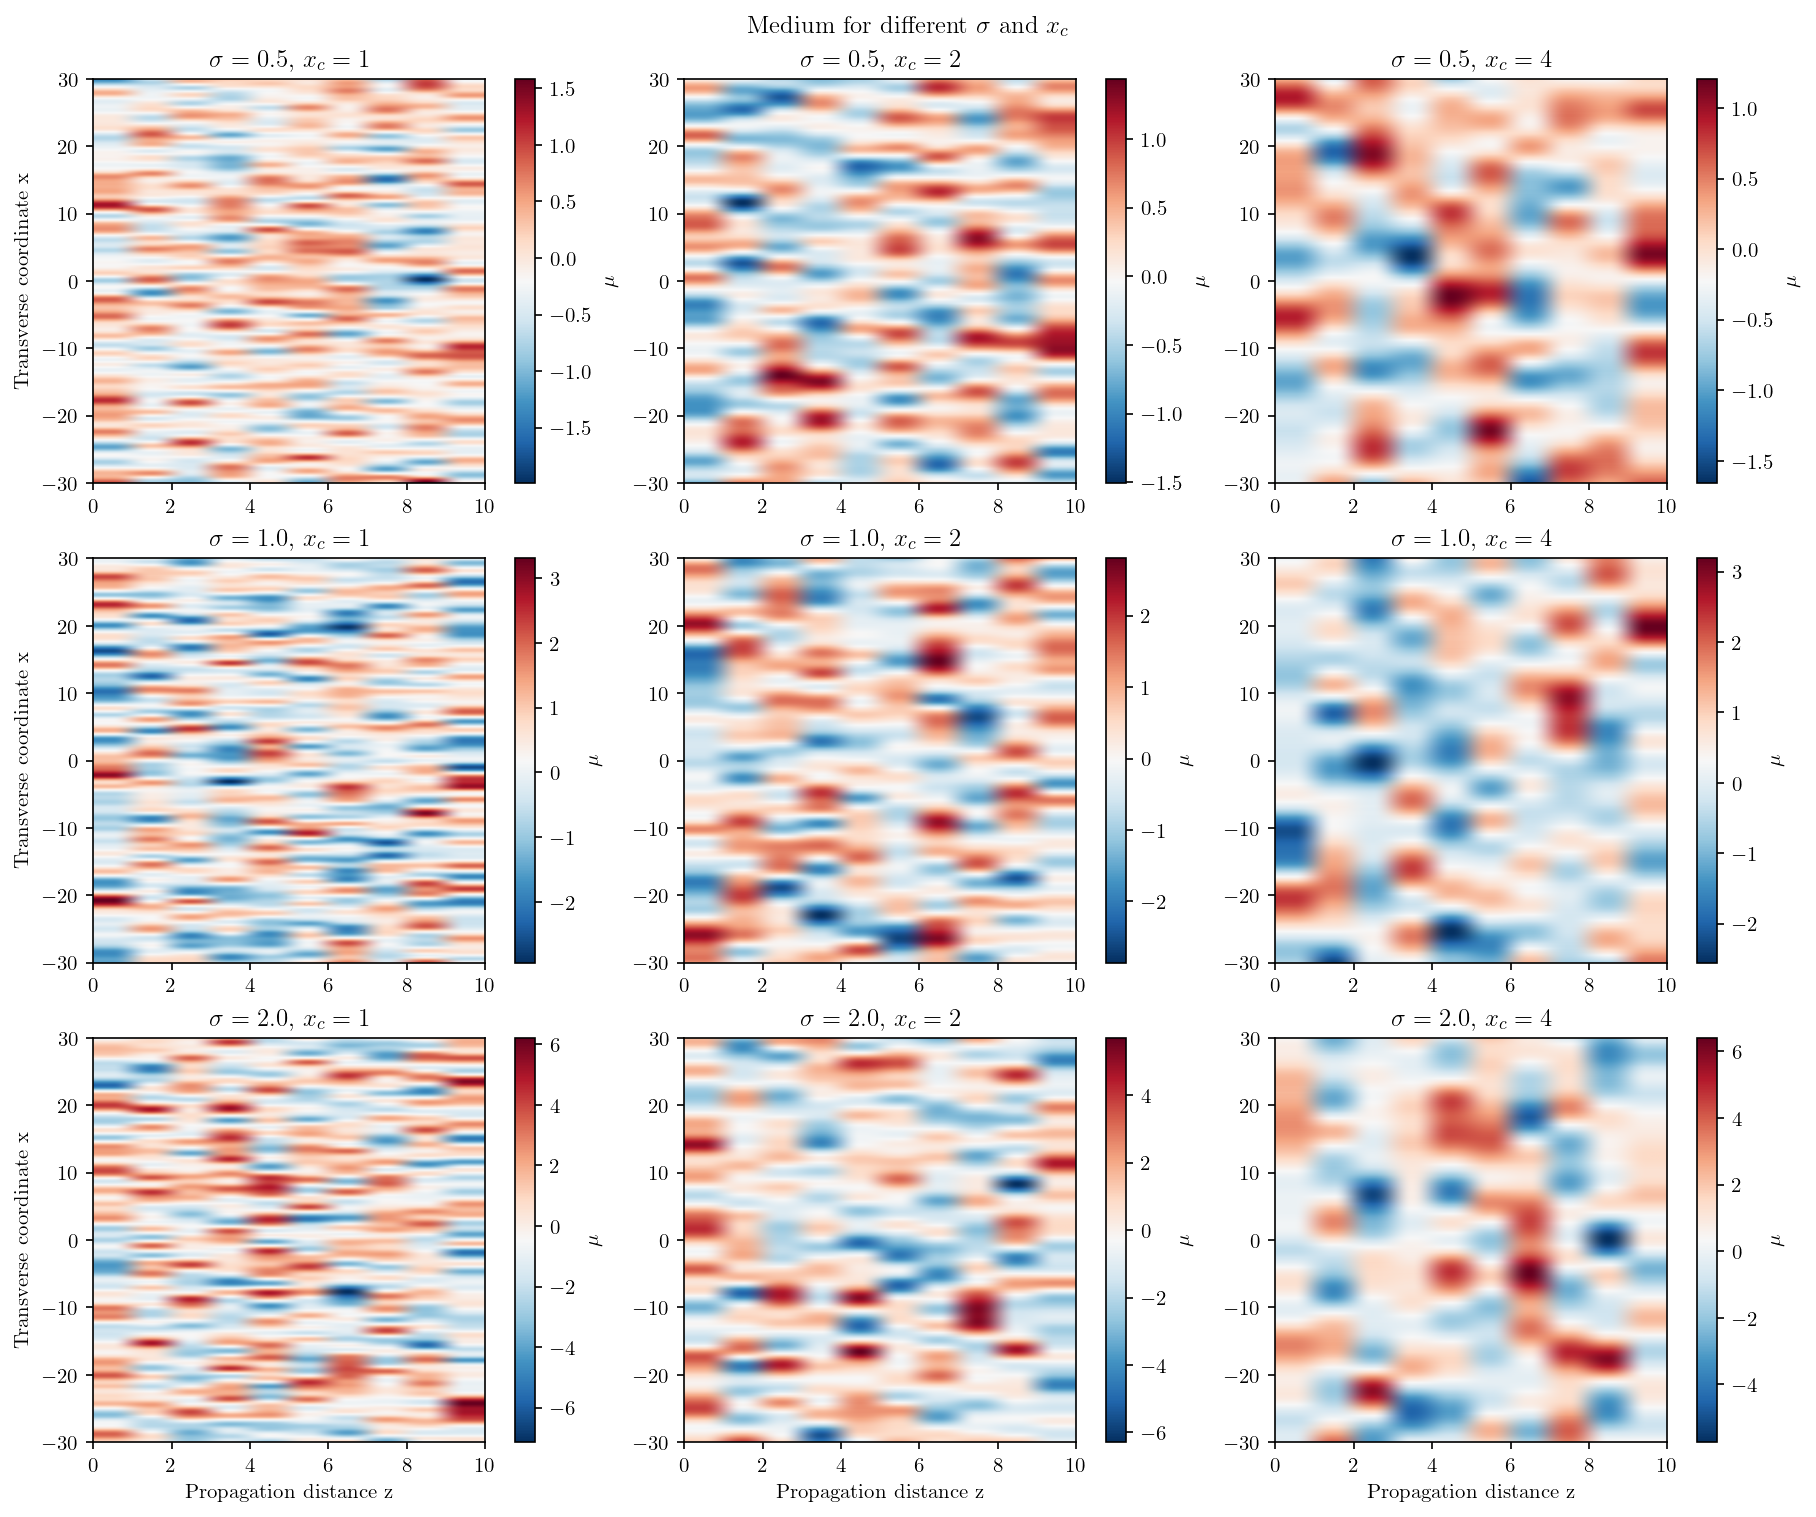

In [10]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(cfg.x_min, cfg.x_max, cfg.nx)
sigmas = [0.5, 1.0, 2.]
xcs = [1, 2, 4]

n_layers = int(cfg.L / cfg.z_c)

fig, axs = plt.subplots(len(sigmas), len(xcs), figsize=(12, 10), constrained_layout=True)

for i, sigma in enumerate(sigmas):
    for j, xc in enumerate(xcs):
        gp = StationaryGaussianProcess(
            mean=0.0, 
            covariance_function=lambda x, xc=xc, sigma=sigma: covariance_function(x, xc, sigma)
        )
        medium = gp.sample(x, n_samples=n_layers)
        
        im = axs[i, j].imshow(
            medium.T,
            aspect='auto',
            cmap='RdBu_r',
            extent=[0, cfg.L, cfg.x_min, cfg.x_max],
        )
        
        fig.colorbar(im, ax=axs[i, j], label=r'$\mu$')

        if i == len(sigmas) - 1:
            axs[i, j].set_xlabel("Propagation distance z")
        if j == 0:
            axs[i, j].set_ylabel("Transverse coordinate x")
            
        axs[i, j].set_title(rf"$\sigma = {sigma}$, $x_c = {xc}$")
fig.suptitle(r"Medium for different $\sigma$ and $x_c$");

Throughout the medium, the layered structure is visible along the $z$-axis. Moreover, we observed that the lower $x_c$ is, the more "scattered" the medium appears. We can then observe the propagation of $\phi$ in a random medium with different noise levels.

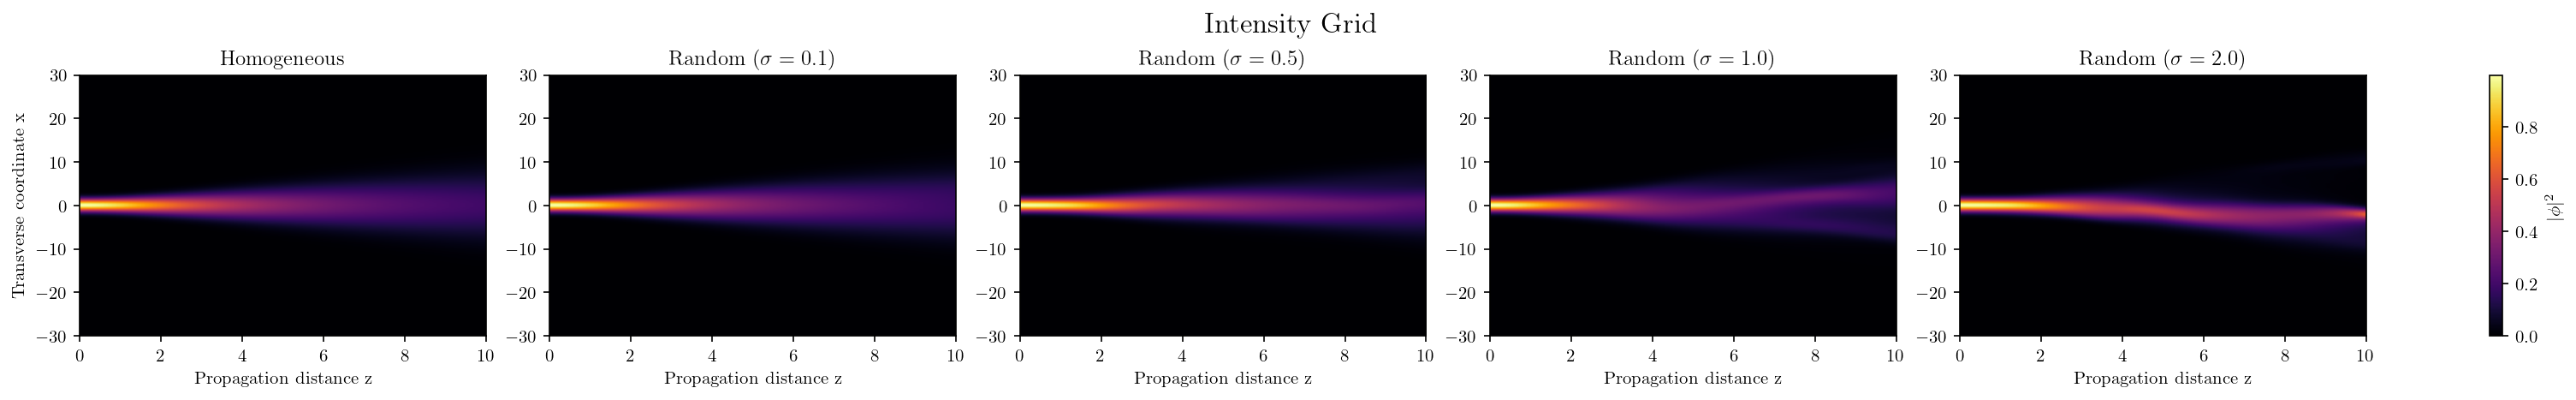

In [11]:
intensity_grid = []
col_labels = []

# Re-initialize basic config
cfg.r_m = 20.0
cfg.mirror_type="gaussian"

for sigma in [0.0, 0.1, 0.5, 1.0, 2.0]:
    cfg_random = dataclasses.replace(cfg, sigma=sigma)

    # Run a single realization
    res_rnd = run_single_simulation(cfg_random, return_history=True)
    n_steps = res_rnd.history.shape[0]
    forward_history = res_rnd.history[: n_steps // 2, :]

    intensity_grid.append(np.abs(forward_history).T ** 2)
    col_labels.append(
        "Homogeneous" if sigma < 1e-5 else rf"Random ($\sigma = {sigma}$)"
    )

plot_intensity_grid(
    [intensity_grid],
    row_labels=[""],
    col_labels=col_labels,
    extent=[0, cfg.L, cfg.x_min, cfg.x_max],
    show=True,
)


We notice how the propagation breaks into a complex interference pattern as the scattering strength increases.

### Monte Carlo Averaging
To recover the theoretical coherent field $\mathbb{E}[\phi_t(x)]$, we must average over many realizations of the random medium. Theory dictates that the mean coherent field decays exponentially
$$\mathbb{E}[\phi_t(x)] = \frac{r_0}{r_t} \exp\left(-\frac{x^2}{r_t^2}\right) \exp\left( - \frac{\gamma_0 \omega^2 L}{8}\right)$$
where $\gamma_0 = \sigma^2 z_c$.


In [12]:
def monte_carlo_simulation(cfg: SimulationConfig, x: np.ndarray):
    """Run Monte Carlo simulations to extract the coherent mean field."""
    all_fields = []
    iterator = tqdm.tqdm(
        range(cfg.n_monte_carlo), desc=rf"Monte Carlo ($\sigma$={cfg.sigma:.2f})"
    )

    for _ in iterator:
        sol = run_single_simulation(cfg, return_history=True)
        n_steps = sol.history.shape[0]
        forward_history = sol.history[: n_steps // 2, :]
        all_fields.append(forward_history[-1])

    mean_field_numerical = np.mean(all_fields, axis=0)  # E[phi]

    mean_field_theoretical = mean_intensity(
        x=x,
        r0=cfg.r0,
        k_const=cfg.k_const,
        L=cfg.L,
        sigma=cfg.sigma,
        z_c=cfg.z_c,
        c0=cfg.c0,
    ) #E[phi] theoretical
    return mean_field_numerical, all_fields, mean_field_theoretical


Monte Carlo ($\sigma$=1.00): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 64.11it/s]


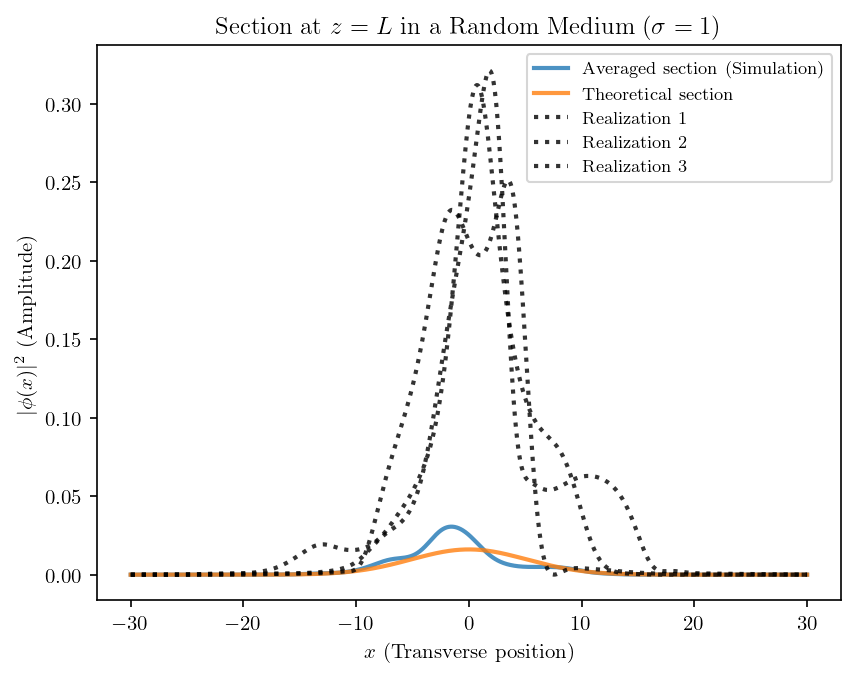

In [13]:
cfg.sigma = 1.0
x = np.linspace(cfg.x_min, cfg.x_max, cfg.nx)

mean_field_num, all_fields, mean_field_theo = monte_carlo_simulation(cfg, x=x)

data = [
    (mean_field_num, "Averaged section (Simulation)", None),
    (mean_field_theo, "Theoretical section", None),
    (all_fields[0], "Realization 1", ":k"),
    (all_fields[20], "Realization 2", ":k"),
    (all_fields[50], "Realization 3", ":k"),
]

plot_multiple_intensity_section(
    x,
    data_list=data,
    title=r"Section at $z=L$ in a Random Medium ($\sigma=1$)",
    show=True,
);


Averaging across 100 runs helps the numerical results match the theory. However, looking at individual realizations, they are clearly far from the mean, suggesting a very high variance.

## Time Reversal in a Random Medium

We will now compare the refocused profiles while varying the mirror size ($r_M$) and scattering strength ($\sigma$).


In [14]:
def monte_carlo_random_medium_time_reversal(
    cfg: SimulationConfig, x: np.ndarray, phi_init_ref: np.ndarray
):
    mc_result = run_monte_carlo_simulation(
        cfg, n_simulations=cfg.n_monte_carlo, compute_intensity_map=True, verbose=False
    )
    mean_theory = mean_field_random_medium_refocused(
        x,
        r0=cfg.r0,
        k_const=cfg.k_const,
        c0=cfg.c0,
        L=cfg.L,
        sigma=cfg.sigma,
        z_c=cfg.z_c,
        r_m=cfg.r_m,
        x_c=cfg.x_c,
    )
    return mc_result.mean_field, mean_theory, mc_result.single_realization_history


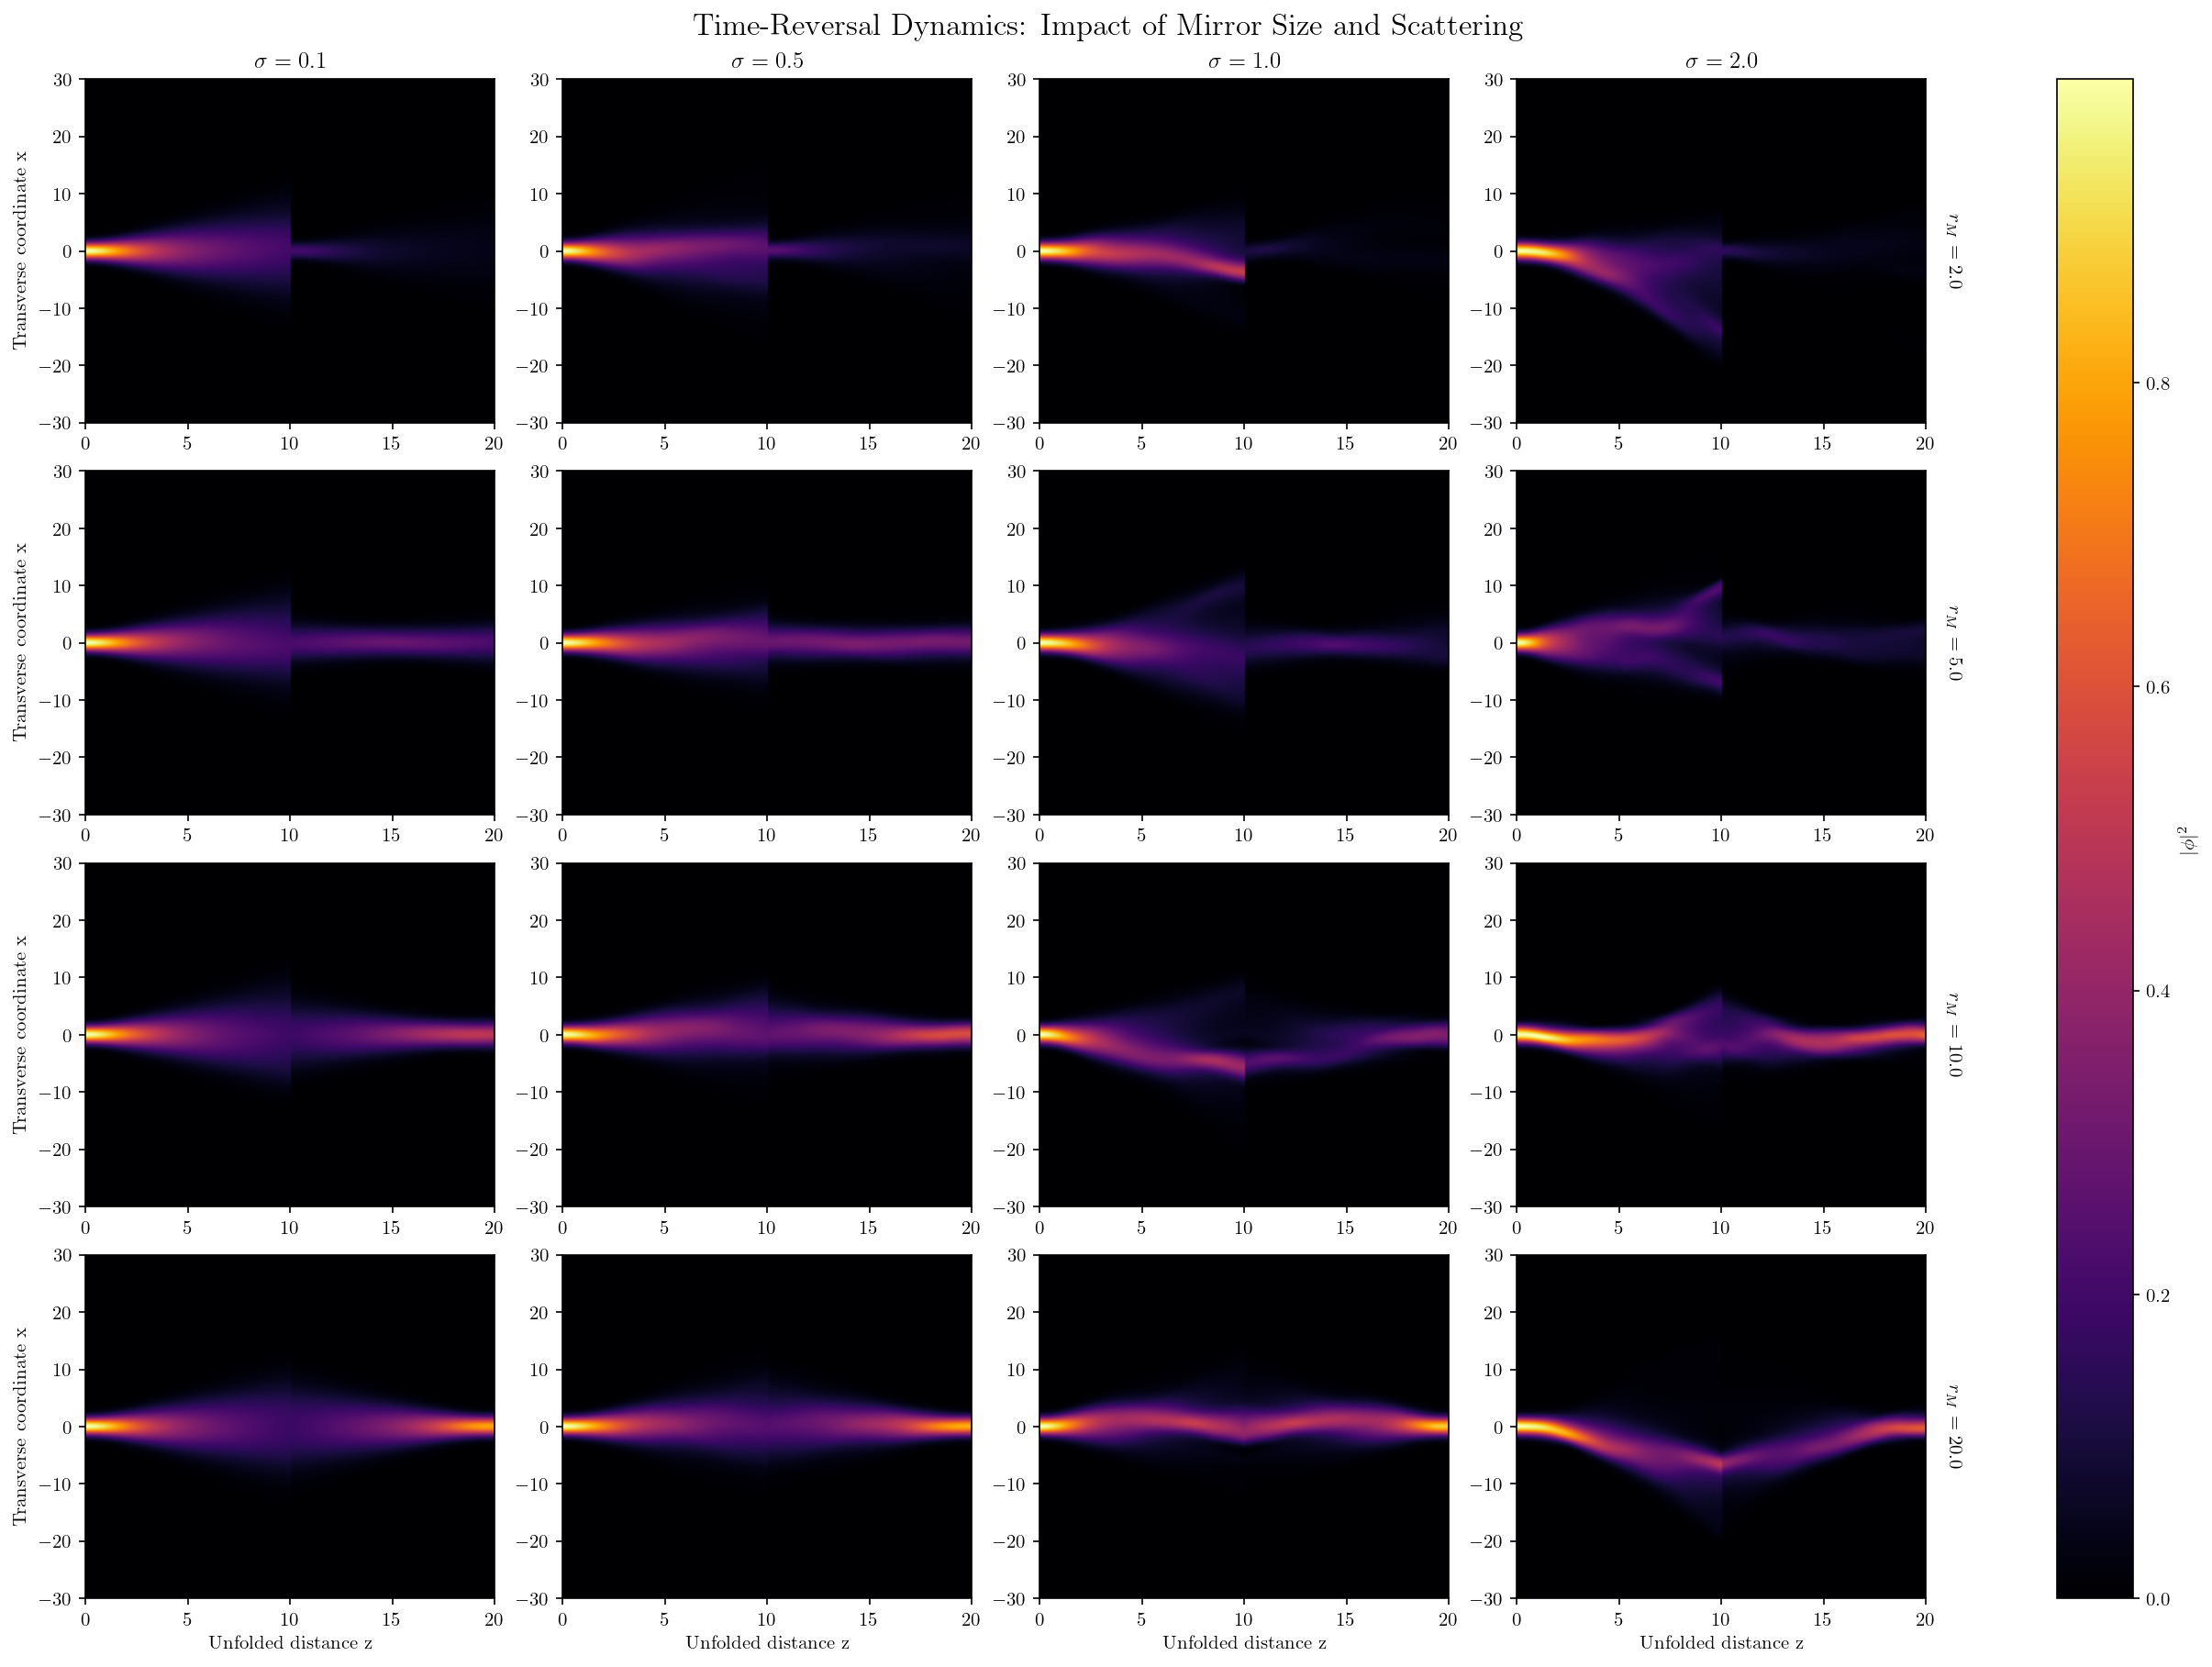

In [15]:
phi_init_ref = init_homogeneous(x, cfg.r0)

rms = [2.0, 5.0, 10.0, 20.0]
sigmas = [0.1, 0.5, 1.0, 2.0]

intensity_grid_data = []
row_labels = [f"$r_M={rm}$" for rm in rms]
col_labels = [rf"$\sigma={s}$" for s in sigmas]

for rm in rms:
    cfg.r_m = rm
    row_data = []
    for sigma in sigmas:
        cfg.sigma = sigma
        _, _, history = monte_carlo_random_medium_time_reversal(cfg, x, phi_init_ref)
        row_data.append(np.abs(history).T ** 2)
    intensity_grid_data.append(row_data)

plot_intensity_grid(
    intensity_grid_data,
    row_labels=row_labels,
    col_labels=col_labels,
    extent=[0, 2 * cfg.L, cfg.x_min, cfg.x_max],
    xlabel="Unfolded distance z",
    ylabel="Transverse coordinate x",
    title="Time-Reversal Dynamics: Impact of Mirror Size and Scattering",
    show=True,
)


This confirms what was previously observed in the homogeneous case: a larger mirror leads to better refocusing and higher peak intensity. In the next section, we will examine the impact of the noise level, focusing particularly on the super-resolution phenomenon.

### Super-Resolution
Let's closely inspect the refocused sections at $z=2L$.

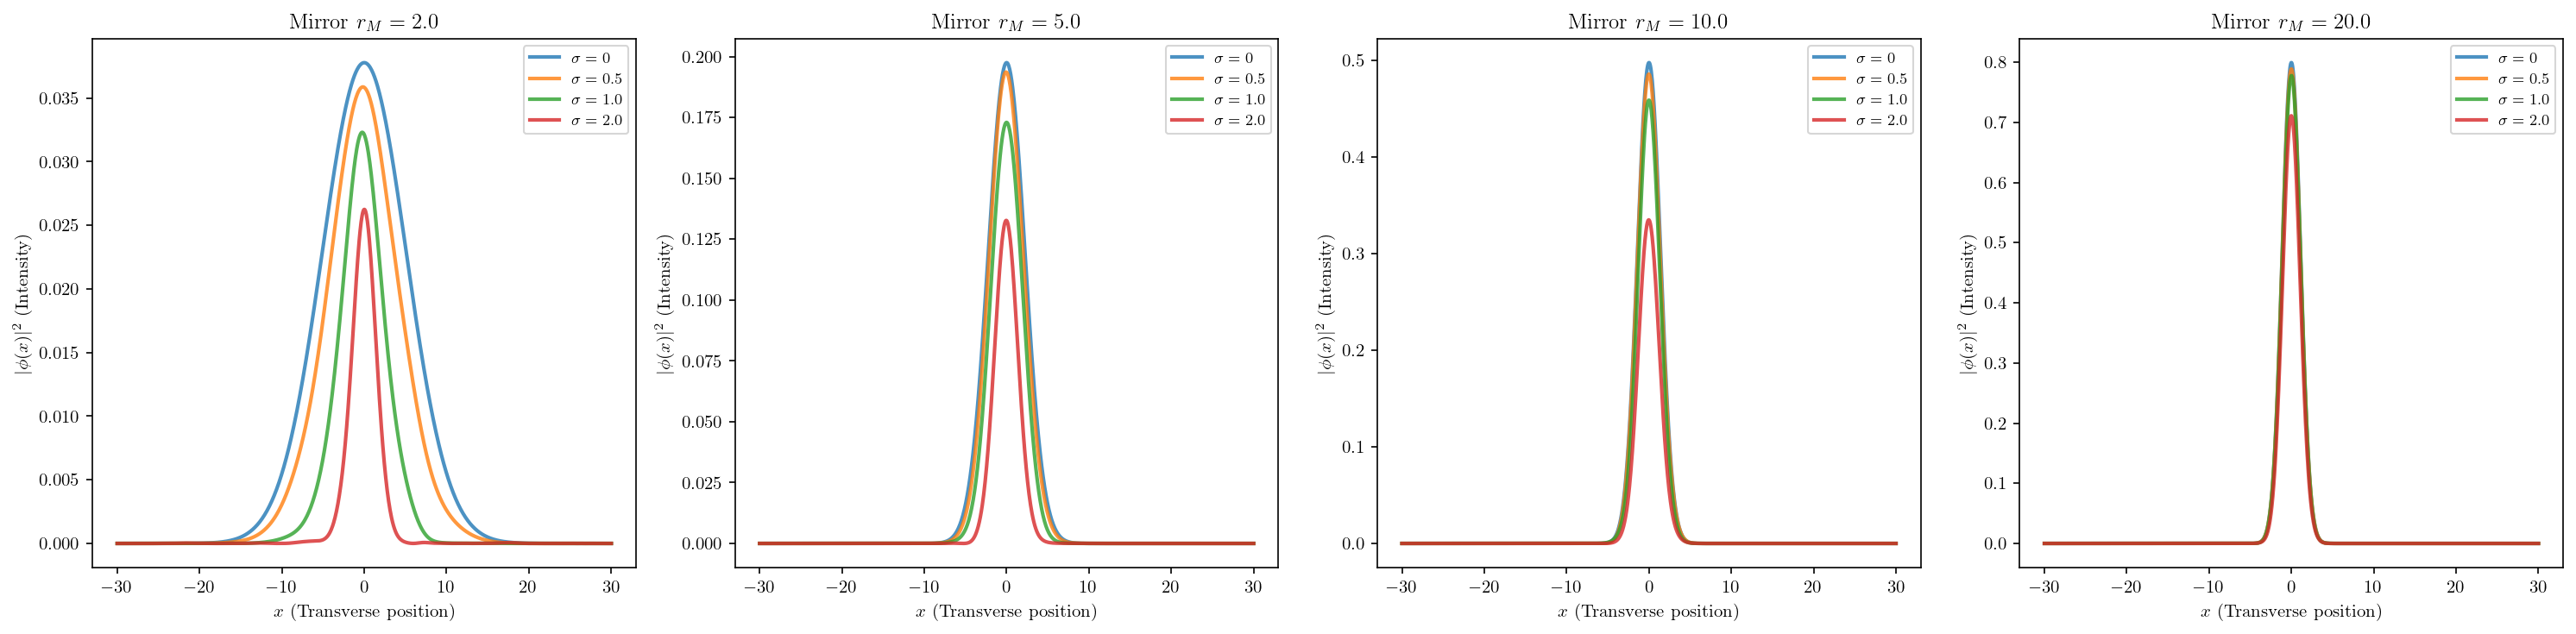

In [16]:
fig, axs = plt.subplots(1, len(rms), figsize=(20, 5))

for i, rm in enumerate(rms):
    cfg.r_m = rm
    data_plot = []
    for sigma in [0, 0.5, 1.0, 2.0]:
        cfg.sigma = sigma
        mean_field, _, _ = monte_carlo_random_medium_time_reversal(cfg, x, phi_init_ref)
        data_plot.append((mean_field, rf"$\sigma={sigma}$", None))

    plot_multiple_intensity_section(
        x,
        data_list=data_plot,
        ax=axs[i],
        title=rf"Mirror $r_M={rm}$",
        xlabel=r"$x$ (Transverse position)",
        ylabel=r"$|\phi(x)|^2$ (Intensity)",
        show=False,
    )
plt.tight_layout()
plt.show()

For a very small mirror (eg $r_M=2$), the homogeneous medium ($\sigma=0$) yields a broad, poorly refocused section. However, as we increase scattering ($\sigma$), the refocused spot becomes progressively sharper. The random medium acts as an extended lens, redirecting lost information back into the small mirror's aperture.


### Quantitative Validation
Let's compare the numerical refocused wave with the theoretical expectation:
$$\mathbb{E}[\phi_r^{tr}(x)] = \frac{1}{a_{tr}} \exp\left( - \frac{x^2}{r_{tr}^2} \right) \exp\left( - \frac{x^2}{r_a^2}\right)$$
where $r_a^{-2} = \gamma_2 \omega^2 \frac{L}{48}$ and $\gamma_2 = 2 \sigma^2 \frac{z_c}{x_c^2}$.
We will then compare on the next plot $\lvert \mathbb{E}[\phi_r^{tr}(x)] \rvert^2$ and $\lvert \frac{1}{N_{sim}} \sum_i \phi_r^{tr, (i)}(x) \rvert^2$.


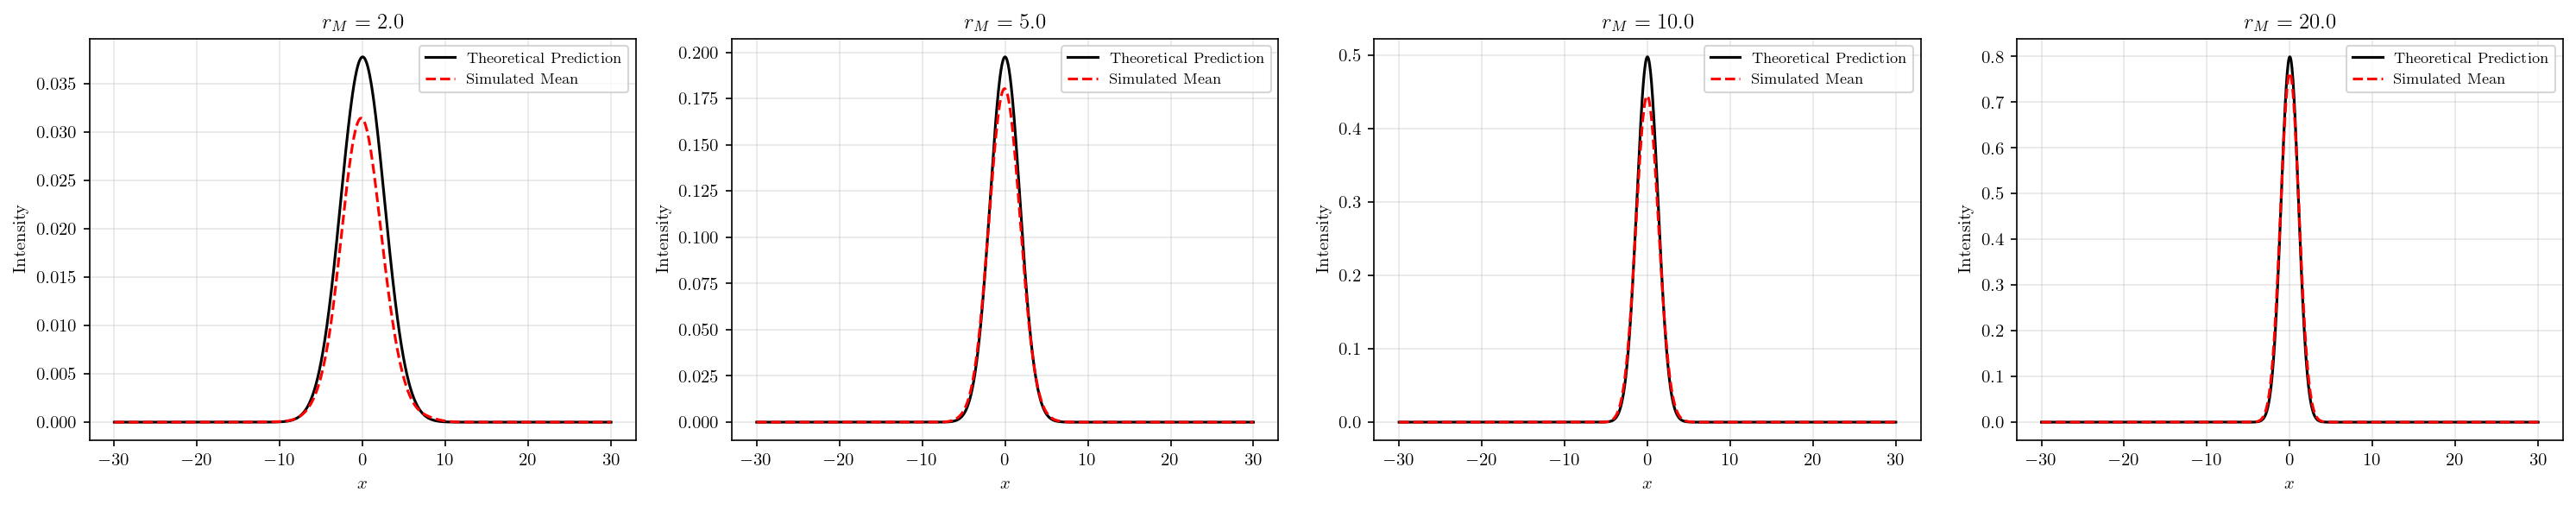

In [17]:
cfg.sigma = 1.0  # Set a fixed scattering strength for validation
fig, axs = plt.subplots(1, len(rms), figsize=(20, 4))

for i, rm in enumerate(rms):
    cfg.r_m = rm
    mean_field, mean_theory, _ = monte_carlo_random_medium_time_reversal(
        cfg, x, phi_init_ref
    )

    plot_intensity_section(
        x,
        mean_field,
        mean_theory,
        ax=axs[i],
        title=rf"$r_M={rm}$",
        xlabel=r"$x$",
        ylabel=r"Intensity",
        label_curve1="Simulated Mean",
        label_curve2="Theoretical Prediction",
        show=False,
    )
plt.tight_layout()
plt.show()


It is observed that the peak shapes remain fairly similar; however, the amplitudes diverge slightly as $r_M$ approaches 0. The cause of this divergence is not yet fully clear. One hypothesis is that the variance of the Monte Carlo estimator increases as $r_M$ decreases.

### The Importance of Reversing in the same Random Medium
We now consider the case where the scattered wave is recorded but back-propagated through a homogeneous medium instead of the original random medium. In this scenario, the theoretical mean refocused profile degrades significantly to
$$\mathbb{E}[\phi_r^{tr}(x)] = \frac{1}{a_{tr}} \exp \left( - \frac{x^2}{r_{tr}^2} \right) \exp\left( - \frac{\gamma_0 \omega^2 L}{8} \right).$$


In [18]:
def monte_carlo_mixed_medium_time_reversal(
    cfg: SimulationConfig, x: np.ndarray, phi_init_ref: np.ndarray
):
    """Simulates forward propagation in a random medium, but back-propagation in a homogeneous one."""
    mc_result = run_monte_carlo_simulation(
        cfg,
        n_simulations=cfg.n_monte_carlo,
        compute_intensity_map=True,
        verbose=False,
        mixed=True,
    )
    mean_theory = mean_field_mixed_medium_refocused(
        x,
        r0=cfg.r0,
        k_const=cfg.k_const,
        c0=cfg.c0,
        L=cfg.L,
        sigma=cfg.sigma,
        z_c=cfg.z_c,
        r_m=cfg.r_m,
    )
    return mc_result.mean_field, mean_theory, mc_result.single_realization_history

#### Demonstration with a small mirror (r_M=2.0)

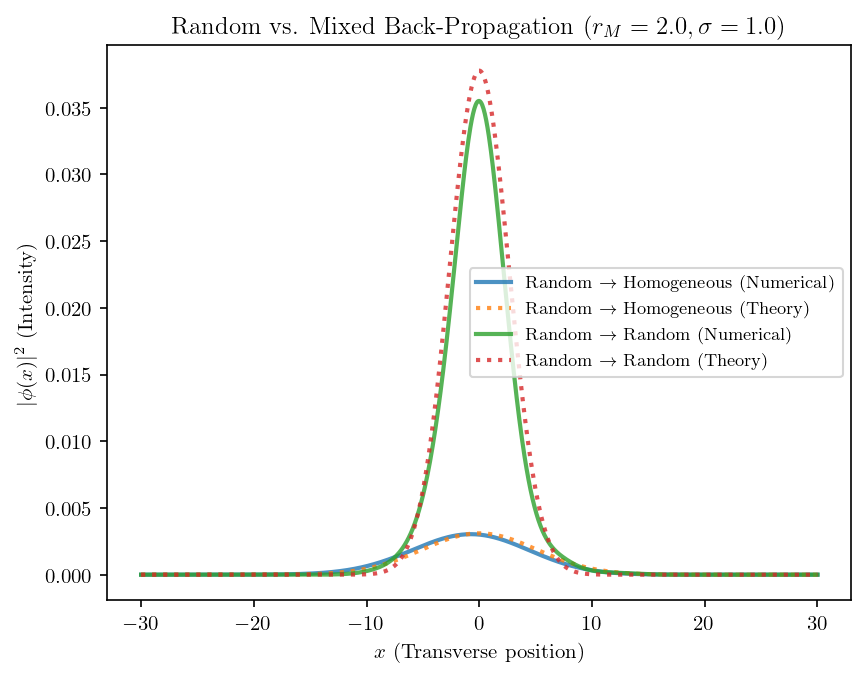

In [19]:
cfg.r_m = 2.0
cfg.sigma = 1.0

data = []
# Mixed medium experiment
mean_field_mixed, theory_mixed, _ = monte_carlo_mixed_medium_time_reversal(
    cfg, x, phi_init_ref
)
data.append((mean_field_mixed, r"Random $\to$ Homogeneous (Numerical)", None))
data.append((theory_mixed, r"Random $\to$ Homogeneous (Theory)", ":"))

# Matched medium experiment
mean_field_matched, theory_matched, _ = monte_carlo_random_medium_time_reversal(
    cfg, x, phi_init_ref
)
data.append((mean_field_matched, r"Random $\to$ Random (Numerical)", None))
data.append((theory_matched, r"Random $\to$ Random (Theory)", ":"))

plot_multiple_intensity_section(
    x,
    data,
    ax=None,
    title=r"Random vs. Mixed Back-Propagation ($r_M=2.0, \sigma=1.0$)",
    xlabel=r"$x$ (Transverse position)",
    ylabel=r"$|\phi(x)|^2$ (Intensity)",
    show=True,
);

This confirms that super-resolution only occurs when the back-propagation leverages the exact same scattering paths. If the medium is wiped clean, refocusing is degraded.

## Time Reversal for Broadband Waves

To simulate a realistic physical pulse, we use a time-dependent initial condition with a flat frequency spectrum over $[\omega_0 - B, \omega_0 + B]$. We synthesize the time-domain pulse by linearly superimposing the monochromatic solutions.
### Statistical Stability (Self-Averaging)
In random media, time-reversed broadband waves exhibit statistical stability. As the bandwidth increases, the refocused intensity profile becomes independent of the specific realization of the random medium, reducing the need for monte-carlo averaging.


In [20]:
def run_broadband_realization(cfg, omegas, realization_seed):
    total_refocused_field = np.zeros(cfg.nx, dtype=complex)
    for w in tqdm.tqdm(
        omegas, desc=f"Freq Loop (Seed {realization_seed})", leave=False
    ):
        cfg_w = dataclasses.replace(cfg, w=w)
        np.random.seed(realization_seed)
        res = run_single_simulation(cfg_w, return_history=False, use_fast_solver=True)
        total_refocused_field += res.phi_final
    return total_refocused_field

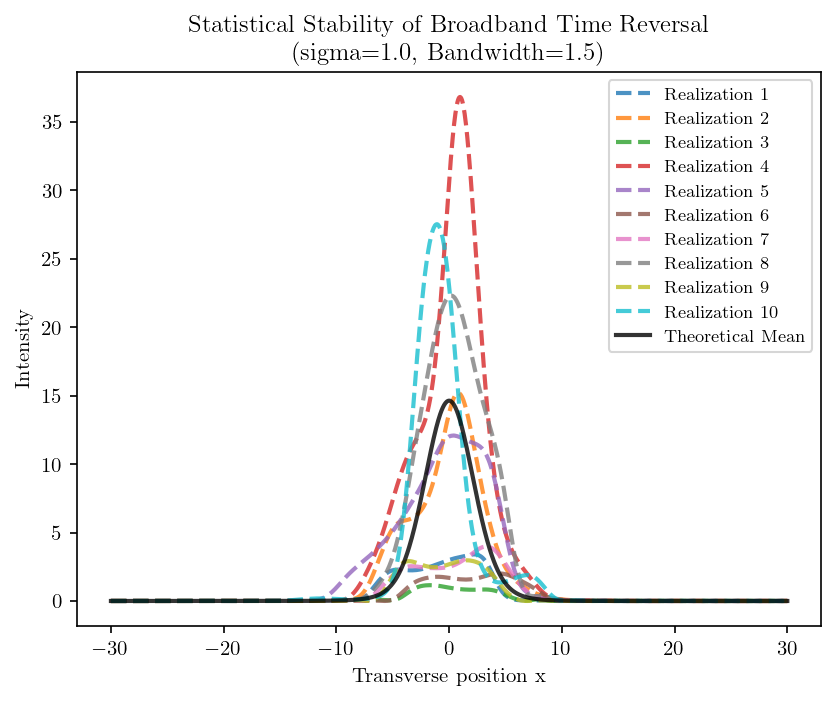

In [21]:
# Parameters
n_freq = 20
delta_omega = 0.75
omegas = np.linspace(cfg.w - delta_omega, cfg.w + delta_omega, n_freq)

# Calculate Theoretical Benchmark
cfg_random = dataclasses.replace(cfg, sigma=1.0, r_m=2.0)
x_random = np.linspace(cfg_random.x_min, cfg_random.x_max, cfg_random.nx)
theory_field = compute_theoretical_broadband_refocused(
    x_random,
    cfg_random.r0,
    c0=cfg_random.c0,
    L=cfg_random.L,
    sigma=cfg_random.sigma,
    z_c=cfg_random.z_c,
    r_m=cfg_random.r_m,
    x_c=cfg_random.x_c,
    omegas=omegas,
)

n_realizations_demo = 10
data_plot_bb = []

for i in range(n_realizations_demo):
    seed = 42 + i
    field = run_broadband_realization(cfg_random, omegas, realization_seed=seed)
    data_plot_bb.append((field, f"Realization {i+1}", "--"))


data_plot_bb.append((theory_field, "Theoretical Mean", "k-"))


plot_multiple_intensity_section(
    x_random,
    data_list=data_plot_bb,
    title=f"Statistical Stability of Broadband Time Reversal\n(sigma={cfg_random.sigma}, Bandwidth={2*delta_omega})",
    xlabel="Transverse position x",
    ylabel="Intensity",
    show=True,
);

Unlike monochromatic waves, a broadband pulse is theoretically expected to exhibit statistical stability through a phenomenon known as self-averaging. It makes the final profile nearly deterministic and independent of the exact realization of the random medium.

In our simulation, we successfully observe this spatial stabilization: refocusing peak is systematically reconstructed at $x=0$, with a constant width that matches the theoretical predictions across all realizations. However, the amplitude remains highly variable. I may explain this for different reasons:

- **Signal deviation and partial observation:** As it propagates through the highly heterogeneous medium, the signal undergoes random lateral deviations. Because our time-reversal mirror acts as a small, fixed sensor ($r_M = 2.0$), the bulk of the energy sometimes misses this observation window. Consequently, the mirror captures and returns only a random fraction of the energy for each realization. This initial loss of information directly translates into a high variance in the amplitude of the final peak.
- **Limited frequency sampling:** Although summing 20 frequencies is sufficient to stabilize the spatial shape of the signal (its mean), this sample size is too small to completely reduce the amplitude variance. As highlighted in the literature, achieving perfect statistical stability for the intensity would require a much larger number of frequencies to fully smooth out the noise.
- **Error in code?:** I do not exclude to have an error in my code, but I was not able to find one. 

To mitigate these amplitude fluctuations without resorting to an artificially larger sensor (which would mask the super-resolution effect), we subsequently implemented a "Dynamic TRM Placement" approach. This technique consists of laterally shifting the small emission window of the mirror ($r_M=2.0$) to center it exactly on the area where the received signal is maximal. By ensuring that the mirror consistently intercepts the core of the signal despite its deviations, this dynamic alignment stabilizes the peak amplitudes across realizations. This allows us to observe the self-averaging effect in its entirety, yielding a refocused signal that is statistically stable in both spatial resolution and intensity.

#### Dynamic placement

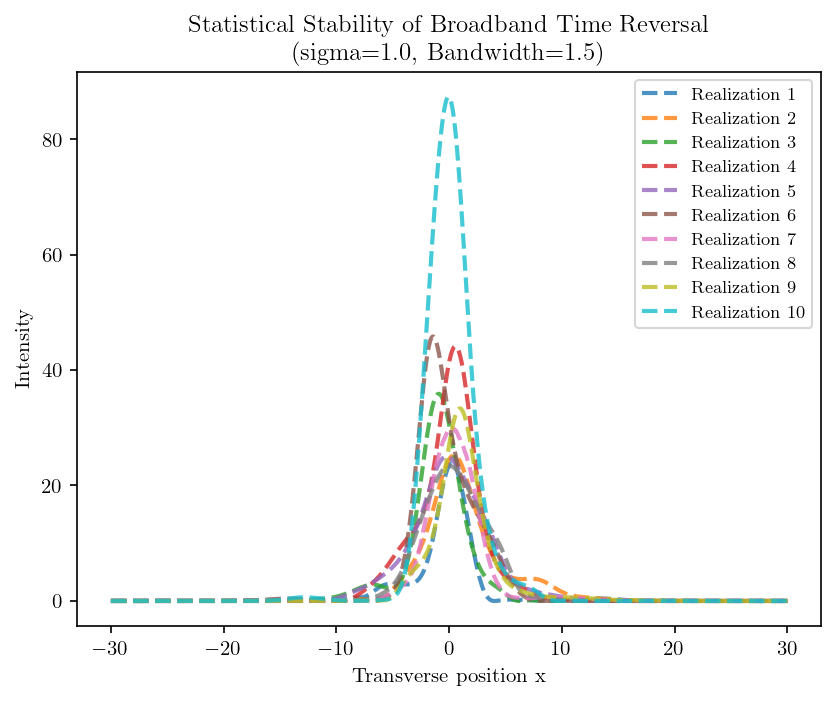

In [22]:
# Broadband Parameters
n_freq = 20
delta_omega = 0.75
omegas = np.linspace(cfg.w - delta_omega, cfg.w + delta_omega, n_freq)

# Calculate Theoretical Benchmark
cfg_random = dataclasses.replace(cfg, sigma=1.0, r_m=2.0, mirror_type="gaussian_adaptive")
x_random = np.linspace(cfg_random.x_min, cfg_random.x_max, cfg_random.nx)
theory_field = compute_theoretical_broadband_refocused(
    x_random,
    cfg_random.r0,
    c0=cfg_random.c0,
    L=cfg_random.L,
    sigma=cfg_random.sigma,
    z_c=cfg_random.z_c,
    r_m=cfg_random.r_m,
    x_c=cfg_random.x_c,
    omegas=omegas,
)

n_realizations_demo = 10
data_plot_bb = []

for i in range(n_realizations_demo):
    seed = 42 + i
    field = run_broadband_realization(cfg_random, omegas, realization_seed=seed)
    data_plot_bb.append((field, f"Realization {i+1}", "--"))

plot_multiple_intensity_section(
    x_random,
    data_list=data_plot_bb,
    title=f"Statistical Stability of Broadband Time Reversal\n(sigma={cfg_random.sigma}, Bandwidth={2*delta_omega})",
    xlabel="Transverse position x",
    ylabel="Intensity",
    show=True,
);

## Broadband Time-Reversal Animation
Let's visualize the full physical pulse dynamically!
We reconstruct the time-domain signal via discrete Fourier synthesis over the computed frequency band. First to confirm the validity of our experiment, we perform time reversal on a big mirror in homogeneous medium.

#### Homogeneous $r_M=20.0$

In [23]:
from IPython.display import Video

import time_reversal.broadband_lib as bb
from time_reversal.viz import animate_wavefield_comparison

cfg_anim = dataclasses.replace(cfg, sigma=0.0, r_m=20.0)
n_freq_anim = 100
delta_omega_anim = 0.75

final_fwd, final_bwd, omegas = bb.run_broadband_parallel(cfg_anim, n_freq=n_freq_anim, delta_omega=delta_omega_anim)

time_to_mirror = cfg.L / cfg.c0

t_grid = np.linspace(0, 6 * time_to_mirror, cfg.nt)
t_grid_back = np.linspace(-6 * time_to_mirror, 0, cfg.nt)

time_fwd = bb.reconstruct_time_domain(final_fwd, omegas, t_grid)
time_bwd = bb.reconstruct_time_domain(final_bwd[:,1:], omegas, t_grid_back)

Simulating frequencies: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 179.73it/s]


In [24]:
output_video = Path("time_reversal_demo_homogeneous.mp4")

print("Rendering MP4 Animation...")
animate_wavefield_comparison(
    time_fwd,
    time_bwd[:, ::-1, :],
    fps=30,
    t_skip=5,
    x_skip=2,
    save_path=output_video,
)

print(f"Animation saved successfully to {output_video}")

# Display the final physical result
Video(output_video, width=800)

Rendering MP4 Animation...
Animation saved successfully to time_reversal_demo_homogeneous.mp4


#### Homogeneous $r_M=2.0$

In [25]:
cfg_anim = dataclasses.replace(cfg, sigma=0.0, r_m=2.0)
n_freq_anim = 100
delta_omega_anim = 0.75

final_fwd, final_bwd, omegas = bb.run_broadband_parallel(cfg_anim, n_freq=n_freq_anim, delta_omega=delta_omega_anim)

time_to_mirror = cfg.L / cfg.c0

t_grid = np.linspace(0, 6 * time_to_mirror, cfg.nt)
t_grid_back = np.linspace(-6 * time_to_mirror, 0, cfg.nt)

time_fwd = bb.reconstruct_time_domain(final_fwd, omegas, t_grid)
time_bwd = bb.reconstruct_time_domain(final_bwd[:,1:], omegas, t_grid_back)

Simulating frequencies: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 130.10it/s]


In [26]:
output_video = Path("time_reversal_demo_homogeneous_2.mp4")

print("Rendering MP4 Animation...")
animate_wavefield_comparison(
    time_fwd,
    time_bwd[:, ::-1, :],
    fps=30,
    t_skip=5,
    x_skip=2,
    save_path=output_video,
)

print(f"Animation saved successfully to {output_video}")

# Display the final physical result
Video(output_video, width=800)

Rendering MP4 Animation...
Animation saved successfully to time_reversal_demo_homogeneous_2.mp4


#### Random $r_M = 10.0$

In [27]:
cfg_anim = dataclasses.replace(cfg, sigma=1.0, r_m=10.0)
n_freq_anim = 100
delta_omega_anim = 0.75

final_fwd, final_bwd, omegas = bb.run_broadband_parallel(cfg_anim, n_freq=n_freq_anim, delta_omega=delta_omega_anim)

time_to_mirror = cfg.L / cfg.c0

t_grid = np.linspace(0, 6 * time_to_mirror, cfg.nt)
t_grid_back = np.linspace(-6 * time_to_mirror, 0, cfg.nt)

time_fwd = bb.reconstruct_time_domain(final_fwd, omegas, t_grid)
time_bwd = bb.reconstruct_time_domain(final_bwd[:,1:], omegas, t_grid_back)

Simulating frequencies: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 148.25it/s]


In [28]:
output_video = Path("time_reversal_demo_10.mp4")

print("Rendering MP4 Animation...")
animate_wavefield_comparison(
    time_fwd,
    time_bwd[:, ::-1, :],
    fps=30,
    t_skip=5,
    x_skip=2,
    save_path=output_video,
)

print(f"Animation saved successfully to {output_video}")

# Display the final physical result
Video(output_video, width=800)

Rendering MP4 Animation...
Animation saved successfully to time_reversal_demo_10.mp4


#### Random $r_M = 5.0$

In [32]:
cfg_anim = dataclasses.replace(cfg, sigma=1.0, r_m=5.0)
n_freq_anim = 100
delta_omega_anim = 0.75

final_fwd, final_bwd, omegas = bb.run_broadband_parallel(cfg_anim, n_freq=n_freq_anim, delta_omega=delta_omega_anim)

time_to_mirror = cfg.L / cfg.c0

t_grid = np.linspace(0, 6 * time_to_mirror, cfg.nt)
t_grid_back = np.linspace(-6 * time_to_mirror, 0, cfg.nt)

time_fwd = bb.reconstruct_time_domain(final_fwd, omegas, t_grid)
time_bwd = bb.reconstruct_time_domain(final_bwd[:,1:], omegas, t_grid_back)

Simulating frequencies: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 124.18it/s]


In [30]:
output_video = Path("time_reversal_demo_5.mp4")

print("Rendering MP4 Animation...")
animate_wavefield_comparison(
    time_fwd,
    time_bwd[:, ::-1, :],
    fps=30,
    t_skip=5,
    x_skip=2,
    save_path=output_video,
)

print(f"Animation saved successfully to {output_video}")

# Display the final physical result
Video(output_video, width=800)

Rendering MP4 Animation...
Animation saved successfully to time_reversal_demo_5.mp4


#### Random 2.0

In [33]:
cfg_anim = dataclasses.replace(cfg, sigma=1.0, r_m=2.0)
n_freq_anim = 100
delta_omega_anim = 0.75

final_fwd, final_bwd, omegas = bb.run_broadband_parallel(cfg_anim, n_freq=n_freq_anim, delta_omega=delta_omega_anim)

time_to_mirror = cfg.L / cfg.c0

t_grid = np.linspace(0, 6 * time_to_mirror, cfg.nt)
t_grid_back = np.linspace(-6 * time_to_mirror, 0, cfg.nt)

time_fwd = bb.reconstruct_time_domain(final_fwd, omegas, t_grid)
time_bwd = bb.reconstruct_time_domain(final_bwd[:,1:], omegas, t_grid_back)

Simulating frequencies: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 98.44it/s]


In [34]:
output_video = Path("time_reversal_demo_2.mp4")

print("Rendering MP4 Animation...")
animate_wavefield_comparison(
    time_fwd,
    time_bwd[:, ::-1, :],
    fps=30,
    t_skip=5,
    x_skip=2,
    save_path=output_video,
)

print(f"Animation saved successfully to {output_video}")

# Display the final physical result
Video(output_video, width=800)

Rendering MP4 Animation...
Animation saved successfully to time_reversal_demo_2.mp4


## The Impact of Medium Granularity ($x_c$)

Throughout this notebook, we varied the scattering strength ($\sigma$) and the mirror size ($r_M$). However, the structure of the random medium itself plays a critical role in super-resolution. We show some numericals experiments below variying $x_c$ at a constant mirror size $r_M=2.0$ and noise $\sigma=1.0$.

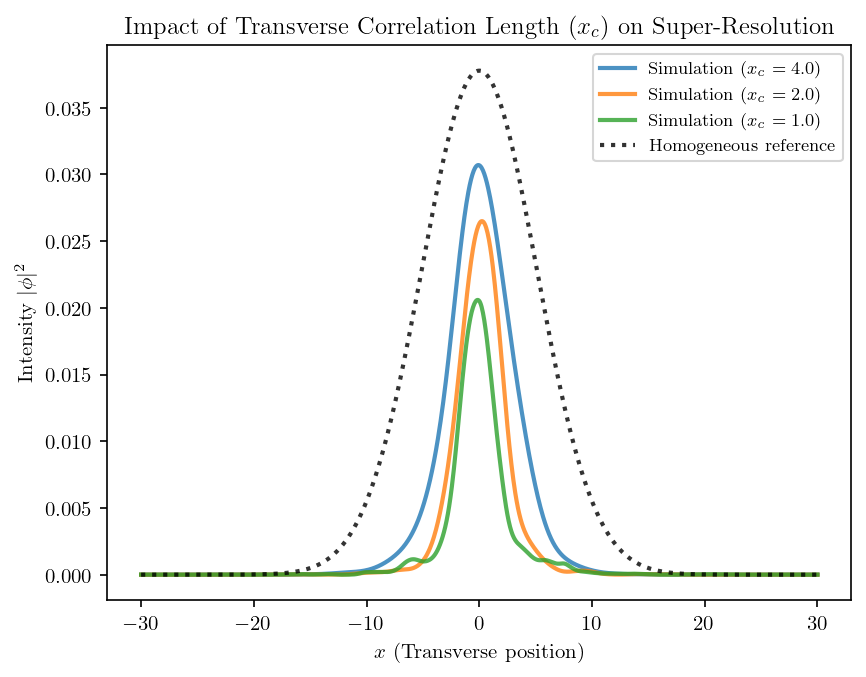

In [31]:
cfg_discuss = dataclasses.replace(cfg, r_m=2.0, sigma=1.0, z_c=1.0)
xc_values = [4.0, 2.0, 1.0]

data_xc_plot = []
colors = ['green', 'orange', 'red']

for xc, color in zip(xc_values, colors):
    cfg_discuss.x_c = xc
    
    mean_field, _, _ = monte_carlo_random_medium_time_reversal(
        cfg_discuss, x, phi_init_ref
    )
    data_xc_plot.append((mean_field, rf"Simulation ($x_c={xc}$)", f"-"))

# Add the homogeneous reference for comparison
cfg_homo = dataclasses.replace(cfg_discuss, sigma=0.0)
mean_homo, _, _ = monte_carlo_random_medium_time_reversal(cfg_homo, x, phi_init_ref)
data_xc_plot.append((mean_homo, "Homogeneous reference", "k:"))

plot_multiple_intensity_section(
    x,
    data_list=data_xc_plot,
    title="Impact of Transverse Correlation Length ($x_c$) on Super-Resolution",
    xlabel=r"$x$ (Transverse position)",
    ylabel=r"Intensity $|\phi|^2$",
    show=True
);

As demonstrated in the plot above, decreasing $x_c$ (making the medium more granular) significantly narrows the refocused spot.